In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import argparse
import sys
from tqdm import tqdm

import src.utils.utils as utils
import src.training.training as training
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may hav

In [2]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
Y_flat = utils.normalize(Y_flat)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

Y = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
H = Y.shape[-1]
Y = Y.to(torch.float32)
Y = Y.unsqueeze(0)

with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [3]:
n_features  = 1
use_cls     = False
extend_cls  = True
fm_name     = "DOFA"
n_features  = 4 if fm_name == "HyperSIGMA" else n_features
patch_size  = 16

if fm_name == "DOFA":
    if H < 224:
        Y = F.interpolate(Y, size=(224,224))
    else:
        H = 224
    Y = Y[:,:,:224, :224]
    fm = rsfm.create_fm(fm_name, Y, n_features=n_features, use_cls=use_cls, extend_cls=extend_cls)
    features = rsfm.get_dofa_features(fm, Y, wavelengths)
    if use_cls:
        D = features.shape[-1]
    else:
        D = int(features.shape[0]/n_features)
        
elif fm_name == "HyperFree":
    n_features = 1
    use_cls = False
    n_patches = H//patch_size
    if n_patches%2 != 0:
        H = (n_patches-1)*patch_size + patch_size-1
    Y = Y[:, :, :H, :H]
    fm = rsfm.create_fm(fm_name, Y, patch_size=patch_size)
    features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
    D = features.shape[0]

elif fm_name == "HyperSIGMA":
    fm = rsfm.create_fm(fm_name, Y, c)
    features = rsfm.get_hypersigma_features(fm, Y)
    D = int(features.shape[1]/n_features)

else:
    pass

if fm_name == "DOFA":
    alpha = int(features.shape[1]**0.5)
    # unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=use_cls)
    unmixer = rsfm.Unmixing_from_features2(D=D, alpha=alpha, B=B, c=c, n_features=n_features)

elif fm_name == "HyperFree":
    alpha = int(features.shape[1]**0.5)
    unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, H=H, n_features=n_features, use_cls=use_cls)

elif fm_name == "HyperSIGMA":
    patch_size = 64
    unmixer = rsfm.Unmixing_from_features(D=D, B=B, c=c, H=patch_size, n_features=n_features, hypersig=True)

else:
    pass

In [4]:
model = unmixer
model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y, c, is_unmixer=True, use_sivm=True)
    
for param in model.abundance_estimator.parameters():
    param.requires_grad = False

print("The unmixer model has : ", format(sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, '.2f'), "M trainable params")
E_hat, A_hat, Y_hat = model(features)
# plt.plot(E_hat.detach().cpu())

The unmixer model has :  86.96 M trainable params


Epoch 0: total = 1.481, SAD = 0.501, MSE = 0.999, Ab = 0.457, TV_E = 242.889, TV_A = 86795.875
Epoch 100: total = 1.168, SAD = 0.210, MSE = 0.999, Ab = 0.427, TV_E = 316.793, TV_A = 75847.094
Epoch 200: total = 1.151, SAD = 0.194, MSE = 0.999, Ab = 0.427, TV_E = 303.188, TV_A = 72206.156
Epoch 300: total = 1.111, SAD = 0.156, MSE = 0.999, Ab = 0.429, TV_E = 262.340, TV_A = 61873.664
Epoch 400: total = 1.096, SAD = 0.141, MSE = 1.000, Ab = 0.431, TV_E = 242.953, TV_A = 53784.086
Epoch 500: total = 1.092, SAD = 0.136, MSE = 1.000, Ab = 0.432, TV_E = 238.259, TV_A = 51605.684
Epoch 600: total = 1.089, SAD = 0.134, MSE = 1.000, Ab = 0.432, TV_E = 234.275, TV_A = 50149.102
Epoch 700: total = 1.088, SAD = 0.132, MSE = 1.000, Ab = 0.433, TV_E = 232.739, TV_A = 48988.781
Epoch 800: total = 1.087, SAD = 0.130, MSE = 1.000, Ab = 0.433, TV_E = 231.692, TV_A = 47301.965
Epoch 900: total = 1.084, SAD = 0.128, MSE = 1.000, Ab = 0.433, TV_E = 230.804, TV_A = 44744.031


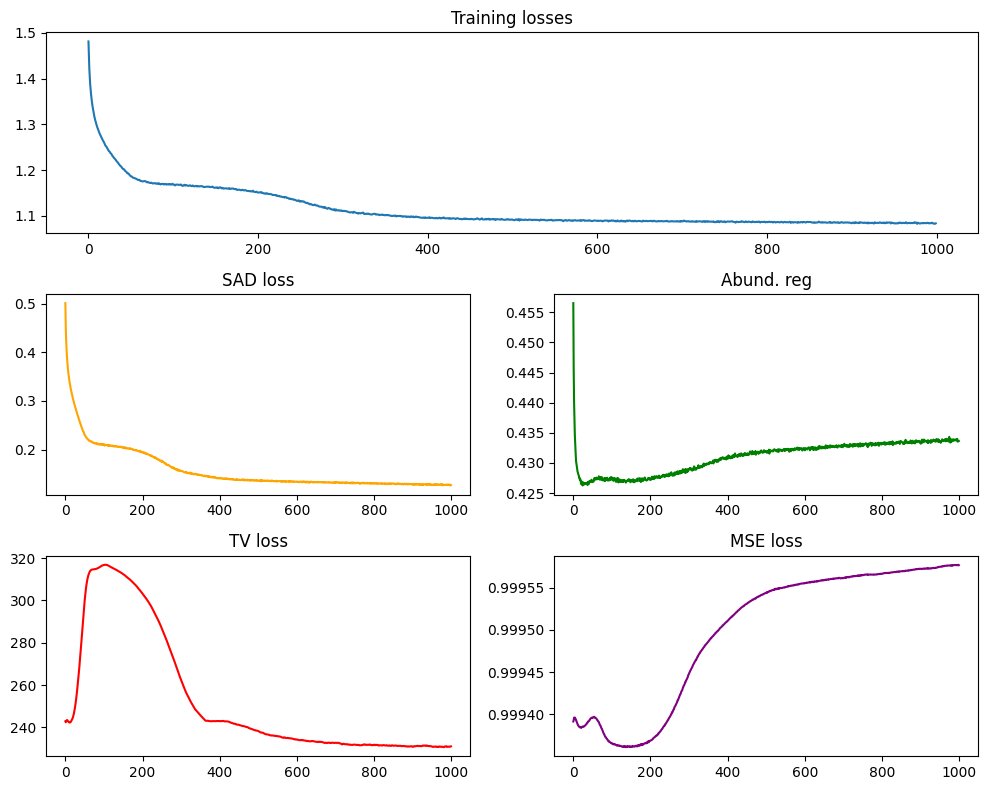

In [5]:
train_losses, sad_losses, ab_losses, tv_e_losses, tv_a_losses, mse_losses = [], [], [], [], [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)

epochs, lr = 1000, 0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in range(epochs):
    
    train_loss, sad_loss, ab_loss, tv_e_loss, tv_a_loss, mse_loss = 0, 0, 0, 0, 0, 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = utils.oneD_to_2d(Y).to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        E = E.to(dev)

        if fm_name == "DOFA":
            if Y.shape[-1] < 224:
                Y = F.interpolate(Y, size=(224,224))
            Y = Y[:,:,:224, :224]
            Y_flat = Y.reshape(1, B, 224**2)
            
            if A.shape[-1] < 224:
                A = F.interpolate(A, size=(224,224))
            A = A[:,:,:224, :224]
            A_flat = A.reshape(1, c, 224**2)

            features = rsfm.get_dofa_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model(features)

        elif fm_name == "HyperFree":
            features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model(features)

        elif fm_name == "HyperSIGMA":
            E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, use_bn=True)

        else:
            pass
        
        W_sad, W_ab, W_tv_e, W_mse = 1, 1, 1e-4, 0.5
        loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse = model.loss(Y, Y_hat, A_hat, E_hat, W_sad=W_sad, W_ab=W_ab, W_tv_e=W_tv_e, W_mse=W_mse, W_tv_a=0)
        train_loss += loss.item()
        sad_loss += loss_sad.item()
        ab_loss += loss_ab.item()
        tv_e_loss += loss_tv_e.item()
        tv_a_loss += loss_tv_a.item()
        mse_loss += loss_mse.item()

        # loss, loss_re, loss_sad, loss_mse = model.supervised_loss(Y, Y_hat, A, A_hat, E[0], E_hat)
        # train_loss += loss.item()

        if epoch%(epochs//10)==0:
            print(f"Epoch {epoch}: total = {format(loss, '.3f')}, SAD = {format(loss_sad, '.3f')}, MSE = {format(loss_mse, '.3f')}, Ab = {format(loss_ab, '.3f')}, TV_E = {format(tv_e_loss, '.3f')}, TV_A = {format(loss_tv_a, '.3f')}")
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    sad_loss /= len(loader)
    ab_loss /= len(loader)
    tv_e_loss /= len(loader)
    tv_a_loss /= len(loader)
    mse_loss /= len(loader)
    train_losses.append(train_loss)
    sad_losses.append(sad_loss)
    ab_losses.append(ab_loss)
    tv_e_losses.append(tv_e_loss)
    tv_a_losses.append(tv_a_loss)
    mse_losses.append(mse_loss)
utils.plot_losses(train_losses, sad_losses, ab_losses, tv_e_losses, mse_losses)
# plt.plot(train_losses)
# plt.title('Training loss')
# plt.show()

Not taking batched E_gt
Not taking batched A_hat
Not taking batched A_gt


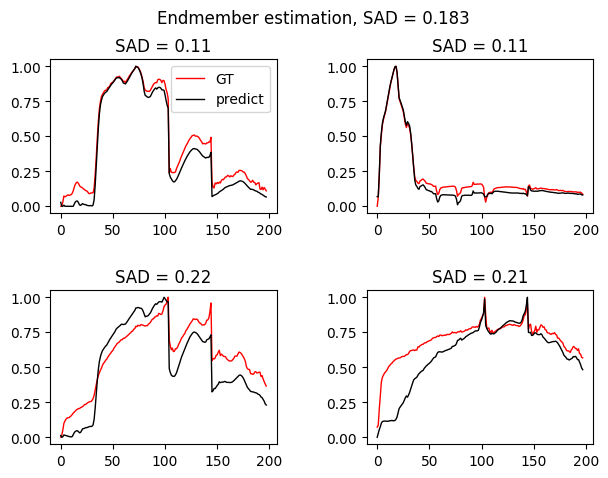

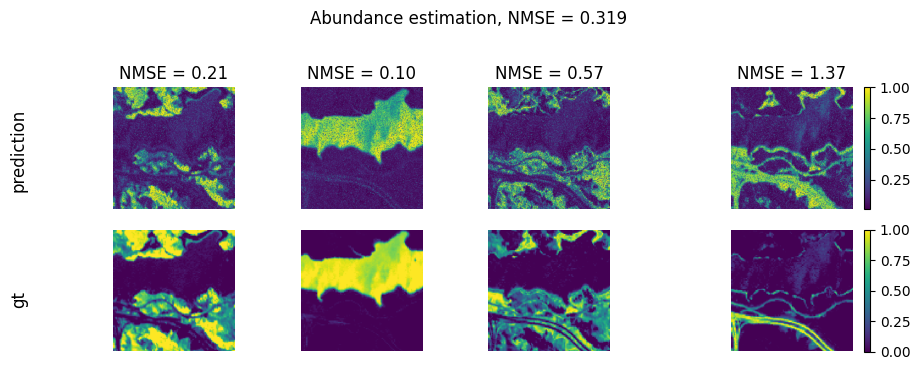

In [6]:
if fm_name == "DOFA" or fm_name == "HyperFree":
    E_hat, A_hat, Y_hat = model(features)

else:
    E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, patch_size=patch_size)
    
utils.plot_results(E_hat, A_hat, A, E, normalize_E=True, normalize_A=True)
E_hat, _, A_hat, _ = utils.order_endmembers(E, E_hat, A_hat)

Epoch 0: total = 1.489, SAD = 0.365, MSE = 0.999, Ab = 0.447, TV_E = 318.379, TV_A = 57249.922
Epoch 50: total = 1.063, SAD = 0.260, MSE = 0.999, Ab = 0.285, TV_E = 318.379, TV_A = 82830.922
Epoch 100: total = 1.032, SAD = 0.251, MSE = 0.999, Ab = 0.275, TV_E = 318.379, TV_A = 82625.523
Epoch 150: total = 1.020, SAD = 0.252, MSE = 0.999, Ab = 0.268, TV_E = 318.379, TV_A = 83881.875
Epoch 200: total = 1.015, SAD = 0.252, MSE = 0.999, Ab = 0.266, TV_E = 318.379, TV_A = 83209.062
Epoch 250: total = nan, SAD = nan, MSE = nan, Ab = nan, TV_E = 318.379, TV_A = nan
Epoch 300: total = nan, SAD = nan, MSE = nan, Ab = nan, TV_E = 318.379, TV_A = nan
Epoch 350: total = nan, SAD = nan, MSE = nan, Ab = nan, TV_E = 318.379, TV_A = nan
Epoch 400: total = nan, SAD = nan, MSE = nan, Ab = nan, TV_E = 318.379, TV_A = nan
Epoch 450: total = nan, SAD = nan, MSE = nan, Ab = nan, TV_E = 318.379, TV_A = nan


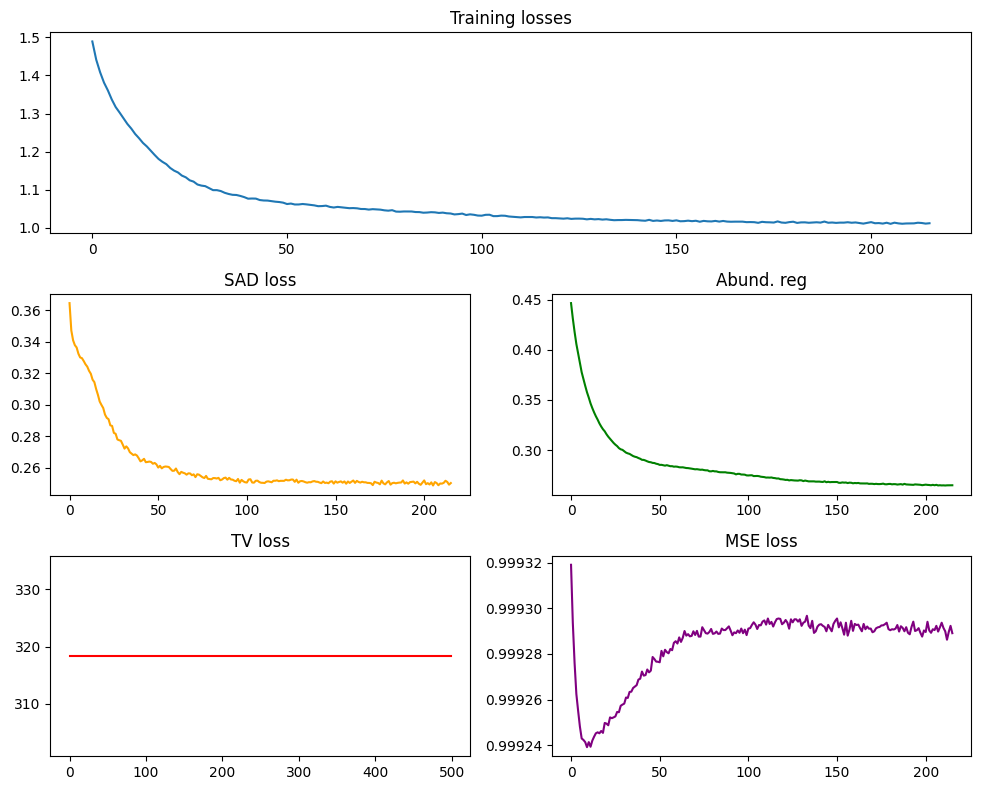

In [7]:
for param in model.decoder.parameters():
    param.requires_grad = False
    
for param in model.abundance_estimator.parameters():
    param.requires_grad = False

for param in model.upsample.parameters():
    param.requires_grad = False

for param in model.abundance_estimator_nobn.parameters():
    param.requires_grad = True

# for layer in model.abundance_estimator_nobn:
#     if isinstance(layer, nn.Conv2d):
#         nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='leaky_relu')

epochs, lr = 500, 0.001
train_losses, sad_losses, ab_losses, tv_e_losses, tv_a_losses, mse_losses = [], [], [], [], [], []
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

for epoch in range(epochs):
    
    train_loss, sad_loss, ab_loss, tv_e_loss, tv_a_loss, mse_loss = 0, 0, 0, 0, 0, 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = utils.oneD_to_2d(Y).to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        E = E.to(dev)

        if fm_name == "DOFA":
            if Y.shape[-1] < 224:
                Y = F.interpolate(Y, size=(224,224))
            Y = Y[:,:,:224, :224]
            Y_flat = Y.reshape(1, B, 224**2)
            
            if A.shape[-1] < 224:
                A = F.interpolate(A, size=(224,224))
            A = A[:,:,:224, :224]
            A_flat = A.reshape(1, c, 224**2)

            features = rsfm.get_dofa_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model.forward_nobn(features)

        elif fm_name == "HyperFree":
            features = rsfm.get_hyperfree_features(fm, Y, wavelengths)
            noise = torch.rand_like(features)
            E_hat, A_hat, Y_hat = model.forward_nobn(features)

        elif fm_name == "HyperSIGMA":
            E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, use_bn=False)

        else:
            pass
        
        W_sad, W_ab, W_tv_e, W_mse = 1, 2, 1e-4, 0.2
        loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse = model.loss(Y, Y_hat, A_hat, E_hat, W_sad=W_sad, W_ab=W_ab, W_tv_e=W_tv_e, W_mse=W_mse, W_tv_a=0)
        train_loss += loss.item()
        sad_loss += loss_sad.item()
        ab_loss += loss_ab.item()
        tv_e_loss += loss_tv_e.item()
        tv_a_loss += loss_tv_a.item()
        mse_loss += loss_mse.item()

        if epoch%(epochs//10)==0:
            print(f"Epoch {epoch}: total = {format(loss, '.3f')}, SAD = {format(loss_sad, '.3f')}, MSE = {format(loss_mse, '.3f')}, Ab = {format(loss_ab, '.3f')}, TV_E = {format(tv_e_loss, '.3f')}, TV_A = {format(loss_tv_a, '.3f')}")
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.abundance_estimator_nobn.parameters(), max_norm=1.0)
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    sad_loss /= len(loader)
    ab_loss /= len(loader)
    tv_e_loss /= len(loader)
    tv_a_loss /= len(loader)
    mse_loss /= len(loader)
    train_losses.append(train_loss)
    sad_losses.append(sad_loss)
    ab_losses.append(ab_loss)
    tv_e_losses.append(tv_e_loss)
    tv_a_losses.append(tv_a_loss)
    mse_losses.append(mse_loss)
utils.plot_losses(train_losses, sad_losses, ab_losses, tv_e_losses, mse_losses)

In [8]:
# if model.__class__.__name__ == "DeepTransDOFA" or model.__class__.__name__ == "DeepTrans":
#     Y_hat = utils.oneD_to_2d(Y_hat)

# utils.compare_hsis(Y, Y_hat)
# plt.imshow(F.interpolate(Y_hat, size=(2000,2000))[0,0].detach().cpu())
# plt.axis("off")
# plt.title("Reconstructed HSI")

Not taking batched E_gt
Not taking batched A_hat
Not taking batched A_gt


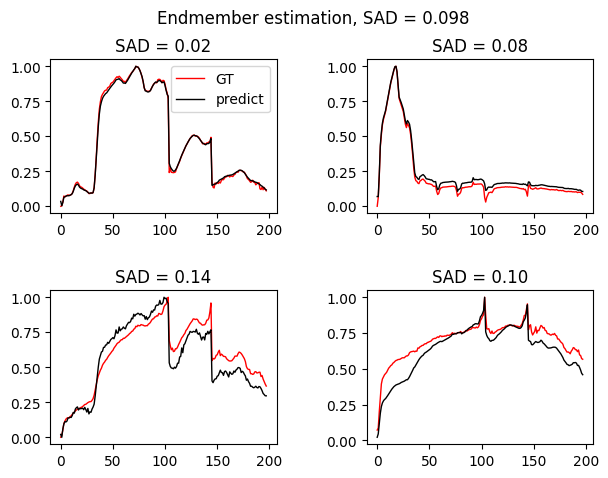

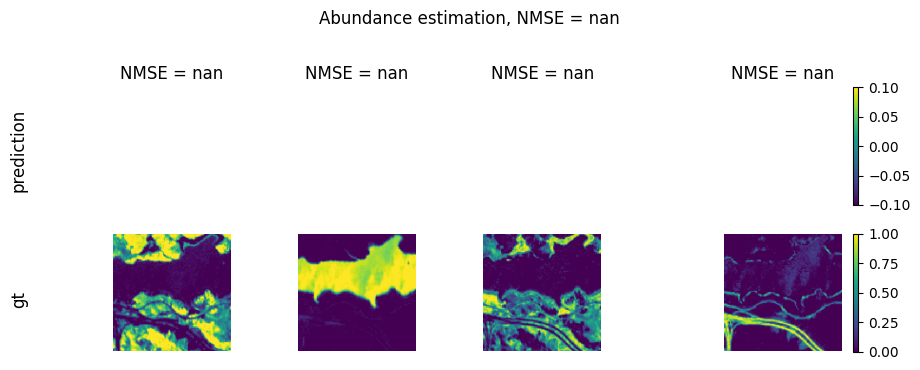

In [9]:
if fm_name == "DOFA" or fm_name == "HyperFree":
    E_hat, A_hat, Y_hat = model(features)

else:
    E_hat, A_hat, Y_hat = rsfm.unmix_full_image_hypersigma(Y, model, fm, c, patch_size=patch_size)
    
utils.plot_results(E_hat, A_hat, A, E, normalize_E=True, normalize_A=True)
E_hat, _, A_hat, _ = utils.order_endmembers(E, E_hat, A_hat)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT")
import models_mae_spectral

torch.serialization.add_safe_globals([argparse.Namespace])
state_dict = torch.load("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT/data/SpectralGPT+.pth", map_location=dev)["model"]

img_size = 128
spectral_gpt = models_mae_spectral.mae_vit_base_patch8_128(num_frames=Y.shape[0], pred_t_dim=Y.shape[0])
# spectral_gpt = models_mae_spectral.__dict__[f"mae_vit_base_patch{patch_size}_{img_size}"]()

encoder_keys = [k for k in state_dict.keys() if k.startswith('patch_embed') or k.startswith('blocks') or k.startswith('norm')]
encoder_state_dict = {k: state_dict[k] for k in encoder_keys}
spectral_gpt.load_state_dict(encoder_state_dict, strict=False)

y_patch = Y.unsqueeze(0)[:,:,:img_size,:img_size]
# y_patch = y_patch.reshape(Y.shape[0], 1, img_size, img_size)
# print(y_patch.shape)
# y_patch = y_patch.reshape(y_patch.shape[0], y_patch[2], y_patch[1], y_patch[3])
latent, _, _ = spectral_gpt.forward_encoder(y_patch, mask_ratio=0.0)

img_size (128, 128) patch_size (8, 8) frames 162 t_patch_size 3
model initialized
torch.Size([1, 1, 162, 128, 128])
torch.Size([1, 1, 162, 128, 128])


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.54 GiB. GPU 0 has a total capacity of 15.89 GiB of which 5.26 GiB is free. Including non-PyTorch memory, this process has 10.63 GiB memory in use. Of the allocated memory 10.19 GiB is allocated by PyTorch, and 150.28 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
sys.path.append("/home/ids/edabier/HSU/HyperFree")
from HyperFree import build_HyperFree_vit_b, predictor

pred = build_HyperFree_vit_b(checkpoint="/home/ids/edabier/HSU/HyperFree/data/HyperFree-b.pth", image_size=batched_Y.shape[2], vit_patch_size=patch_size)
hyperfree = predictor.HyperFree_Predictor(pred)

input_y = hyperfree.transform.apply_image_torch(batched_Y)
hyperfree.set_torch_image(input_y, original_image_size=(Y.shape[1], Y.shape[2]), spectral_lengths=wavelengths, GSD=GSD)
hyperfree.features.shape